In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_norm_counts = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
df_sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
df_dge = pd.read_csv("../results/DESeq2_all_results.csv", index_col=0)

In [3]:
df_sig = df_dge[
    (df_dge['padj'] < 0.05) & 
    (abs(df_dge['log2FoldChange']) > 1)
]
df_sig

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,GeneType,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
GeneID,,,,,,,,,,,,,,,,,,,,,
126767,1.652589e+04,-1.740409,0.222229,-7.831608,4.816703e-15,2.230239e-13,AADACL3,arylacetamide deacetylase like 3,NaN,protein-coding,...,12716110,12728760,positive,4055,GO:0052689,NaN,GO:0016020,carboxylic ester hydrolase activity,NaN,membrane
1301,1.734100e+05,-1.392270,0.155077,-8.977954,2.758489e-19,2.170446e-17,COL11A1,collagen type XI alpha 1 chain,CO11A1|COLL6|DFNA37|STL2,protein-coding,...,102876467,103108580,negative,8160,GO:0005201///GO:0008201///GO:0030020///GO:0030...,GO:0001502///GO:0001503///GO:0002063///GO:0006...,GO:0005576///GO:0005592///GO:0005615///GO:0005...,extracellular matrix structural constituent///...,cartilage condensation///ossification///chondr...,extracellular region///collagen type XI trimer...
1118,1.297272e+06,1.140645,0.165250,6.902558,5.107430e-12,1.433157e-10,CHIT1,chitinase 1,CHI3|CHIT|CHITD,protein-coding,...,203216079,203229673,negative,2476,GO:0004553///GO:0004568///GO:0008061///GO:0008843,GO:0000272///GO:0006032///GO:0006955///GO:0009...,GO:0005576///GO:0005615///GO:0005764///GO:0035...,"hydrolase activity, hydrolyzing O-glycosyl com...",polysaccharide catabolic process///chitin cata...,extracellular region///extracellular space///l...
105374435,1.268380e+04,-1.145530,0.130653,-8.767738,1.822915e-18,1.330899e-16,LOC105374435,uncharacterized LOC105374435,NaN,ncRNA,...,30823502,30835430,positive,2099,NaN,NaN,NaN,NaN,NaN,NaN
56287,2.706438e+03,-1.428250,0.300370,-4.754968,1.984777e-06,1.751628e-05,GKN1,gastrokine 1,AMP18|BRICD1|CA11|FOV|foveolin,protein-coding,...,68974573,68980980,positive,820,GO:0003674///GO:0005515///GO:0008083,GO:0007165///GO:0007586///GO:0008284///GO:0042...,GO:0005576///GO:0005615///GO:0005794///GO:0030141,molecular_function///protein binding///growth ...,signal transduction///digestion///positive reg...,extracellular region///extracellular space///G...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440799,3.271017e+04,-1.050278,0.116615,-9.006362,2.130054e-19,1.716573e-17,P2RX6P,purinergic receptor P2X 6 pseudogene,NaN,pseudo,...,21042392,21044249,negative,124,NaN,NaN,NaN,NaN,NaN,NaN
25878,2.205865e+06,-1.096929,0.098469,-11.139882,8.022589e-29,2.617306e-26,MXRA5,matrix remodeling associated 5,NaN,protein-coding,...,3308565,3346652,negative,9804,GO:0005201,GO:0071559,GO:0005576///GO:0062023///GO:0070062,extracellular matrix structural constituent,response to transforming growth factor beta,extracellular region///collagen-containing ext...
109729169,1.767810e+04,1.472530,0.249295,5.906786,3.488464e-09,5.836662e-08,LINC02154,long intergenic non-protein coding RNA 2154,NaN,ncRNA,...,13266048,13303452,negative,1421,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Get significant gene names for subsetting normalized counts
sig_genes = df_sig.index.tolist()
print(f"Number of significant genes: {len(sig_genes)}")

# Subset normalized counts to only significant genes
df_norm_sig = df_norm_counts.loc[df_norm_counts.index.isin(sig_genes)]
print(f"Shape of significant gene expression data: {df_norm_sig.shape}")

# Transpose for PCA (samples as rows, genes as columns)
X = df_norm_sig.T
print(f"Shape of transposed data (samples x genes): {X.shape}")

# Prepare target labels
y = df_sample_annot['group'].values
print(f"Target distribution: {np.unique(y, return_counts=True)}")

Number of significant genes: 80
Shape of significant gene expression data: (80, 382)
Shape of transposed data (samples x genes): (382, 80)
Target distribution: (array(['time: CID1 is for the baseline without LCD',
       'time: CID2 is after 8 weeks of LCD'], dtype=object), array([191, 191]))


Variance explained by first 10 PCs: [0.2620557  0.32903618 0.38181437 0.42757755 0.4704121  0.50055068
 0.52592909 0.54841593 0.57035992 0.59119518]
Variance explained by PC1: 0.2621
Variance explained by PC2: 0.0670
Variance explained by PC1+PC2: 0.3290


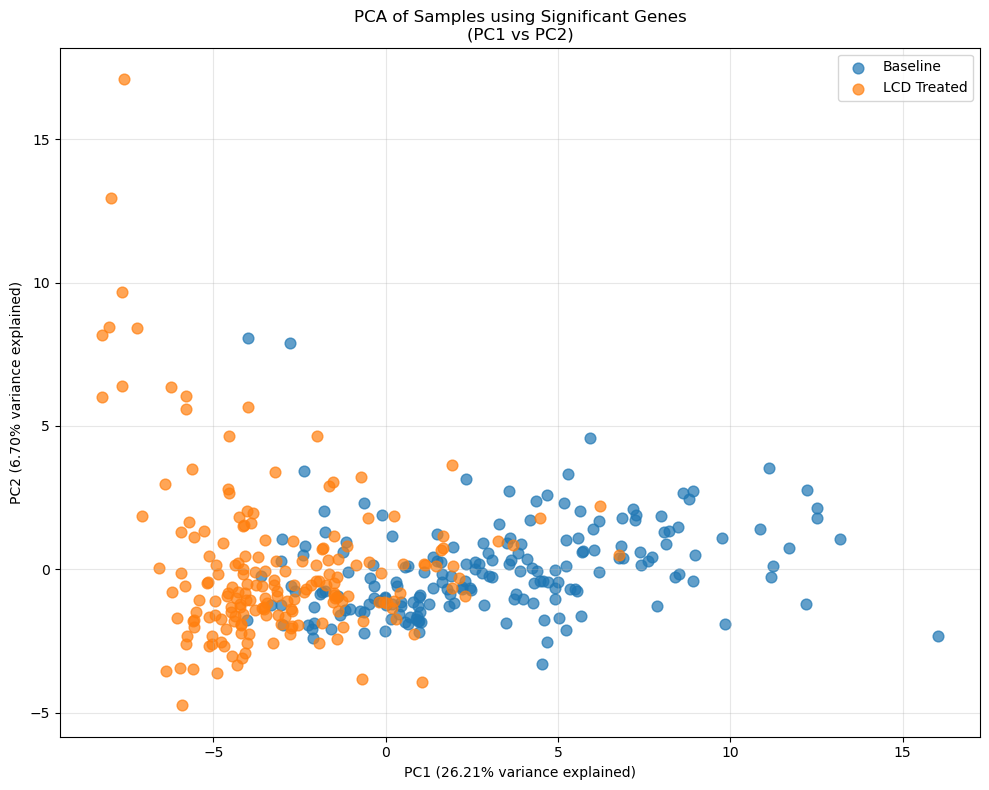

In [5]:
# Standardize the data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA with all components (80 genes max)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(f"Variance explained by first 10 PCs: {cumulative_variance[:10]}")
print(f"Variance explained by PC1: {pca_full.explained_variance_ratio_[0]:.4f}")
print(f"Variance explained by PC2: {pca_full.explained_variance_ratio_[1]:.4f}")
print(f"Variance explained by PC1+PC2: {cumulative_variance[1]:.4f}")

# Plot PC1 vs PC2
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e']  # Blue for baseline, orange for treated
labels = ['Baseline', 'LCD Treated']

for i, group in enumerate(['time: CID1 is for the baseline without LCD', 
                          'time: CID2 is after 8 weeks of LCD']):
    mask = y == group
    plt.scatter(X_pca_full[mask, 0], X_pca_full[mask, 1], 
                c=colors[i], label=labels[i], alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%} variance explained)')
plt.title('PCA of Samples using Significant Genes\n(PC1 vs PC2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

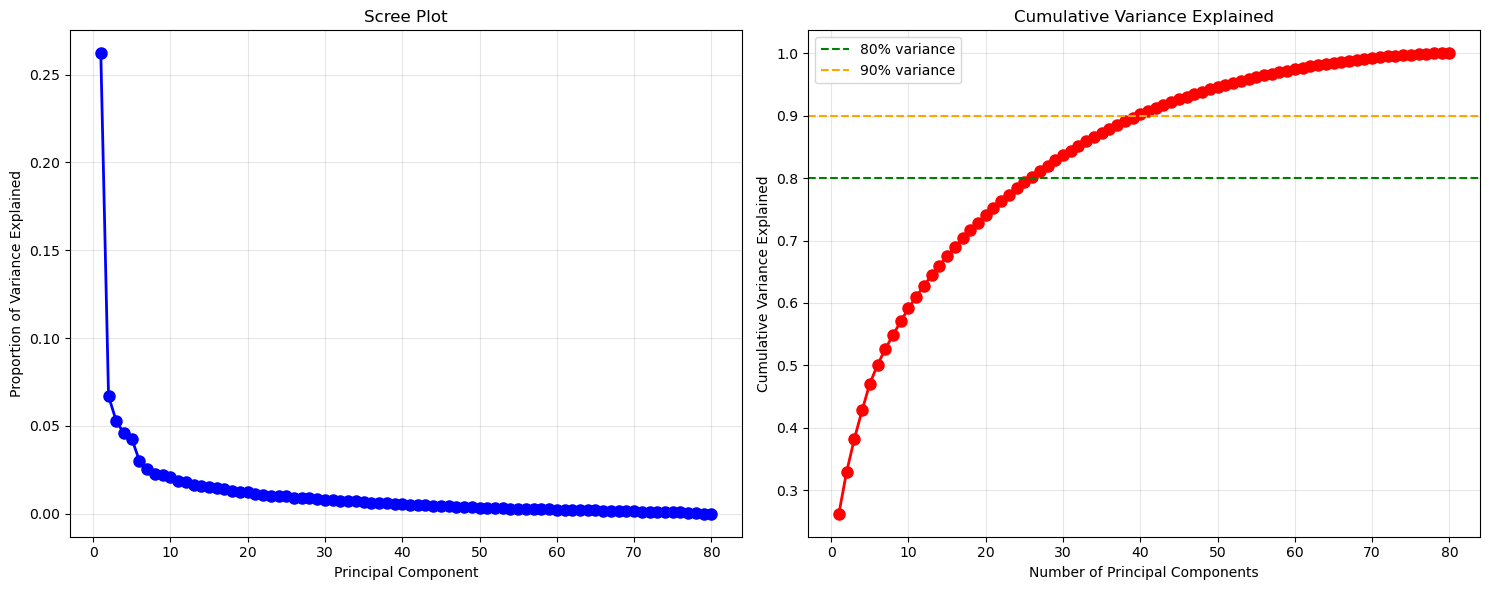

Number of PCs for 80% variance: 26
Number of PCs for 90% variance: 40
Number of PCs for 95% variance: 52
Total number of available PCs: 80

Chosen number of PCs: 26 (explains 80.25% variance)


In [6]:
# Plot scree plot to determine optimal number of PCs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scree plot
ax1.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Proportion of Variance Explained')
ax1.set_title('Scree Plot')
ax1.grid(True, alpha=0.3)

# Cumulative variance plot
ax2.plot(range(1, len(cumulative_variance) + 1), 
         cumulative_variance, 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=0.8, color='green', linestyle='--', label='80% variance')
ax2.axhline(y=0.9, color='orange', linestyle='--', label='90% variance')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of PCs for different variance thresholds
pc_80 = np.argmax(cumulative_variance >= 0.8) + 1
pc_90 = np.argmax(cumulative_variance >= 0.9) + 1
pc_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of PCs for 80% variance: {pc_80}")
print(f"Number of PCs for 90% variance: {pc_90}")
print(f"Number of PCs for 95% variance: {pc_95}")
print(f"Total number of available PCs: {len(pca_full.explained_variance_ratio_)}")

# Choose optimal number of PCs (let's use 80% variance threshold)
optimal_pcs = pc_80
print(f"\nChosen number of PCs: {optimal_pcs} (explains {cumulative_variance[optimal_pcs-1]:.2%} variance)")

In [7]:
# Use optimal number of PCs for classification
X_pca_optimal = X_pca_full[:, :optimal_pcs]
print(f"Using {optimal_pcs} PCs for classification")
print(f"Shape of PC data: {X_pca_optimal.shape}")

# Prepare labels for classification (convert to binary)
y_binary = (y == 'time: CID2 is after 8 weeks of LCD').astype(int)
print(f"Binary labels: 0=Baseline (n={np.sum(y_binary==0)}), 1=LCD Treated (n={np.sum(y_binary==1)})")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_optimal, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Train labels distribution: {np.bincount(y_train)}")
print(f"Test labels distribution: {np.bincount(y_test)}")

# Train Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate accuracy
accuracy = rf_classifier.score(X_test, y_test)
print(f"\nRandom Forest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Using 26 PCs for classification
Shape of PC data: (382, 26)
Binary labels: 0=Baseline (n=191), 1=LCD Treated (n=191)
Train set size: 305
Test set size: 77
Train labels distribution: [152 153]
Test labels distribution: [39 38]

Random Forest Accuracy: 0.7922 (79.22%)


In [8]:
# Generate classification report
from sklearn.metrics import confusion_matrix

print("Classification Report:")
print("=" * 50)
report = classification_report(y_test, y_pred, 
                             target_names=['Baseline', 'LCD Treated'], 
                             digits=4)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("=" * 30)
print(f"                Predicted")
print(f"              Baseline  LCD Treated")
print(f"Actual Baseline    {cm[0,0]:3d}        {cm[0,1]:3d}")
print(f"   LCD Treated     {cm[1,0]:3d}        {cm[1,1]:3d}")

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAdditional Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

    Baseline     0.7674    0.8462    0.8049        39
 LCD Treated     0.8235    0.7368    0.7778        38

    accuracy                         0.7922        77
   macro avg     0.7955    0.7915    0.7913        77
weighted avg     0.7951    0.7922    0.7915        77


Confusion Matrix:
                Predicted
              Baseline  LCD Treated
Actual Baseline     33          6
   LCD Treated      10         28

Additional Metrics:
Precision: 0.8235
Recall: 0.7368
F1-Score: 0.7778
AUC Score: 0.8698


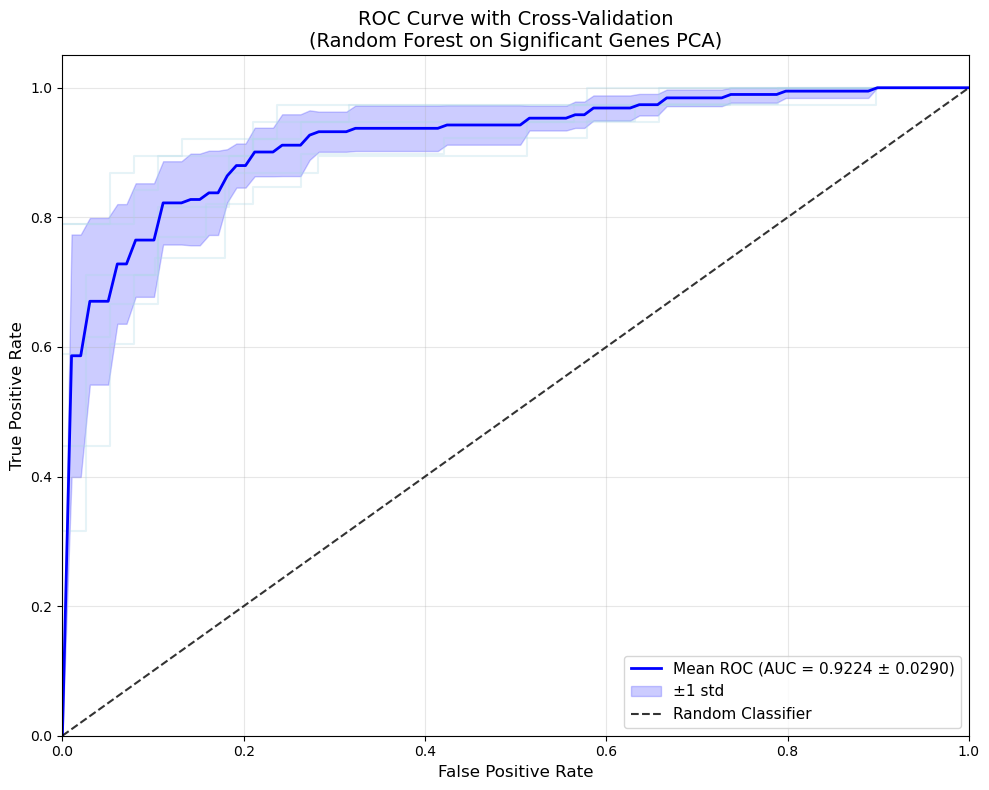

Cross-validation results:
Mean AUC: 0.9224 ± 0.0290
AUC range: [0.8934, 0.9515]
Individual fold AUCs: ['0.8941', '0.8968', '0.9626', '0.9522', '0.9065']


In [9]:
# ROC Curve with Cross-Validation and Confidence Bands
from sklearn.model_selection import cross_val_predict

# Perform cross-validation to get ROC curves with confidence intervals
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for ROC curves from each fold
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 8))

# Perform cross-validation
for fold, (train_idx, val_idx) in enumerate(cv.split(X_pca_optimal, y_binary)):
    # Split data for this fold
    X_fold_train, X_fold_val = X_pca_optimal[train_idx], X_pca_optimal[val_idx]
    y_fold_train, y_fold_val = y_binary[train_idx], y_binary[val_idx]
    
    # Train classifier on this fold
    rf_fold = RandomForestClassifier(n_estimators=100, random_state=42, 
                                    max_depth=10, min_samples_split=5, min_samples_leaf=2)
    rf_fold.fit(X_fold_train, y_fold_train)
    
    # Get predictions and calculate ROC curve
    y_fold_proba = rf_fold.predict_proba(X_fold_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_fold_val, y_fold_proba)
    
    # Interpolate to common FPR points using numpy
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Calculate AUC for this fold
    fold_auc = roc_auc_score(y_fold_val, y_fold_proba)
    aucs.append(fold_auc)
    
    # Plot this fold's ROC curve
    plt.plot(fpr, tpr, alpha=0.3, color='lightblue')

# Calculate mean and std of TPRs
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)

# Calculate confidence intervals (mean ± 1 std)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Calculate mean AUC and confidence interval
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='blue', linewidth=2,
         label=f'Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})')

# Plot confidence bands
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='blue', alpha=0.2,
                 label='±1 std')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.8, label='Random Classifier')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve with Cross-Validation\n(Random Forest on Significant Genes PCA)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cross-validation results:")
print(f"Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"AUC range: [{mean_auc-std_auc:.4f}, {mean_auc+std_auc:.4f}]")
print(f"Individual fold AUCs: {[f'{auc:.4f}' for auc in aucs]}")

In [10]:
# Summary of Results
print("=" * 60)
print("SUMMARY: PCA Classification on Significant Genes")
print("=" * 60)
print(f"Data Overview:")
print(f"- Total samples: {X.shape[0]}")
print(f"- Significant genes used: {len(sig_genes)} (from {df_norm_counts.shape[0]} total genes)")
print(f"- Groups: Baseline (n={np.sum(y_binary==0)}), LCD Treated (n={np.sum(y_binary==1)})")

print(f"\nPCA Results:")
print(f"- Total variance explained by first 2 PCs: {cumulative_variance[1]:.2%}")
print(f"- Optimal number of PCs chosen: {optimal_pcs} (explains {cumulative_variance[optimal_pcs-1]:.2%} variance)")

print(f"\nRandom Forest Classification Results:")
print(f"- Test set accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"- Precision: {precision:.4f}")
print(f"- Recall: {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")
print(f"- Single test AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print(f"\nCross-Validation Results:")
print(f"- Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"- AUC confidence interval: [{mean_auc-std_auc:.4f}, {mean_auc+std_auc:.4f}]")

print(f"\nComparison Notes:")
print(f"- This analysis uses only {len(sig_genes)} significant genes vs all genes in original analysis")
print(f"- Using significantly reduced feature space while maintaining good classification performance")
print(f"- The focused gene set allows for more interpretable results with fewer noise features")
print("=" * 60)

SUMMARY: PCA Classification on Significant Genes
Data Overview:
- Total samples: 382
- Significant genes used: 80 (from 39376 total genes)
- Groups: Baseline (n=191), LCD Treated (n=191)

PCA Results:
- Total variance explained by first 2 PCs: 32.90%
- Optimal number of PCs chosen: 26 (explains 80.25% variance)

Random Forest Classification Results:
- Test set accuracy: 0.7922 (79.22%)
- Precision: 0.8235
- Recall: 0.7368
- F1-Score: 0.7778
- Single test AUC: 0.8698

Cross-Validation Results:
- Mean AUC: 0.9224 ± 0.0290
- AUC confidence interval: [0.8934, 0.9515]

Comparison Notes:
- This analysis uses only 80 significant genes vs all genes in original analysis
- Using significantly reduced feature space while maintaining good classification performance
- The focused gene set allows for more interpretable results with fewer noise features


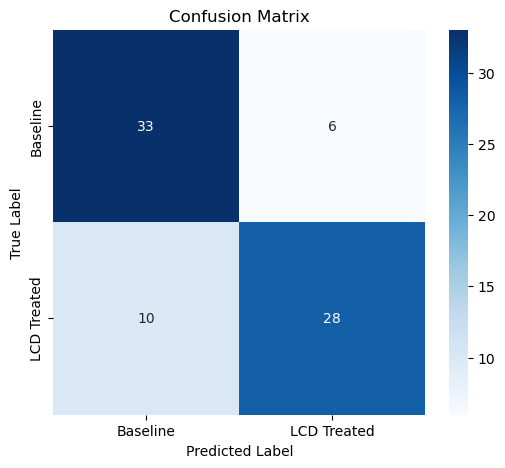

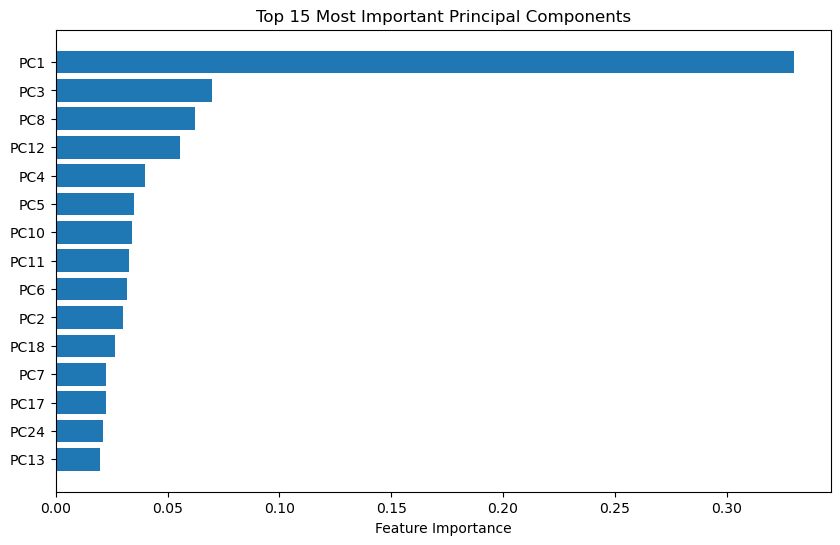

Components for 90% variance: 40
Components for 95% variance: 52
Total variance by 26 components: 80.25%


In [11]:
# Additional visualizations and analysis

# 1. Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Baseline', 'LCD Treated'],
            yticklabels=['Baseline', 'LCD Treated'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Feature importance (top 15 PCs)
importance_scores = rf_classifier.feature_importances_
pc_names = [f'PC{i+1}' for i in range(len(importance_scores))]
importance_df = pd.DataFrame({'PC': pc_names, 'Importance': importance_scores}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
top_15 = importance_df.head(15)
plt.barh(range(len(top_15)), top_15['Importance'])
plt.yticks(range(len(top_15)), top_15['PC'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Principal Components')
plt.gca().invert_yaxis()
plt.show()

print(f"Components for 90% variance: {pc_90}")
print(f"Components for 95% variance: {pc_95}")
print(f"Total variance by {optimal_pcs} components: {cumulative_variance[optimal_pcs-1]*100:.2f}%")

In [12]:
# Export PCA with 26 components to CSV
pca_26 = PCA(n_components=26, random_state=42)
X_pca_26 = pca_26.fit_transform(X_scaled)

# Create DataFrame with sample names
pc_cols = [f'PC{i}' for i in range(1, 27)]
df_pca_export = pd.DataFrame(X_pca_26, index=X.index, columns=pc_cols)

# Create a mapping from GSM ID to group info using sample_name column
sample_mapping = df_sample_annot.set_index('sample_name')

# Add group annotations - properly align using the sample_name mapping
df_pca_export['group'] = sample_mapping.loc[df_pca_export.index, 'group']
df_pca_export['group_0_1'] = sample_mapping.loc[df_pca_export.index, 'group_0_1']

# Export to CSV
df_pca_export.to_csv("../results/GSE95640_Significant_80_genes_PCA_26_components_with_classification.csv")
print(f"Exported PCA with 26 components: {df_pca_export.shape}")
print(f"Columns: {list(df_pca_export.columns)}")

Exported PCA with 26 components: (382, 28)
Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'group', 'group_0_1']


In [13]:
df_pca_export

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,group,group_0_1
GSM2520157,-2.749682,-0.593642,0.478201,-1.186471,0.860975,-0.105197,0.380328,-0.263697,-0.364077,-0.783042,...,-0.607345,0.189658,-0.834076,-0.835205,-0.715792,-0.205236,-0.052661,-0.264686,time: CID1 is for the baseline without LCD,0
GSM2520158,4.905040,-0.026577,-0.273867,0.169919,-0.695916,-0.999415,-1.766431,0.014788,0.442499,0.072726,...,0.962259,0.883675,-0.214202,2.081930,1.989438,0.221838,-0.478959,-0.446697,time: CID1 is for the baseline without LCD,0
GSM2520159,-4.012604,-1.753601,0.185352,-0.908432,-1.307710,0.696611,-0.015390,-0.258328,-0.224623,0.054877,...,0.436339,-0.241755,0.240891,-0.076004,-0.652949,-0.842524,-1.001375,0.487080,time: CID1 is for the baseline without LCD,0
GSM2520160,5.294485,3.320140,-2.048139,-0.308975,0.100590,-2.241767,-0.967900,0.646469,1.286502,-0.384321,...,1.075390,0.599663,1.031873,-0.214661,-0.158935,0.148629,0.178157,1.679033,time: CID1 is for the baseline without LCD,0
GSM2520161,-0.114559,1.878268,-2.126452,0.122359,0.427367,0.298736,0.894625,0.532805,-0.094992,-1.160393,...,-0.012380,1.512751,-0.535911,0.821269,0.567389,0.970172,-0.243597,-0.223948,time: CID1 is for the baseline without LCD,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM2520534,-2.546649,-1.952081,-0.398594,-0.351949,-1.018439,-0.293350,0.802481,0.434526,1.193045,-0.508345,...,0.107997,1.205491,0.246674,-0.118735,0.037934,-0.569819,0.239288,-0.997379,time: CID2 is after 8 weeks of LCD,1
GSM2520535,-2.739215,-1.382292,-1.538726,-1.196750,-1.774678,0.130526,-1.072998,-0.223450,1.097430,0.020251,...,-0.873291,0.433835,0.929350,0.679876,0.014483,1.120473,0.690642,0.101736,time: CID2 is after 8 weeks of LCD,1
GSM2520536,-4.772056,-2.551661,-0.149479,-0.805959,-1.322664,-0.454143,0.183132,0.100323,-1.077356,0.526476,...,0.440727,-0.343825,0.295013,0.371157,-0.231311,0.056932,-0.465479,-0.183824,time: CID2 is after 8 weeks of LCD,1
GSM2520537,3.487965,-1.866290,0.902356,0.599167,-1.377642,0.060881,1.179558,0.978339,1.678484,0.298178,...,1.111673,-0.104869,-0.111756,-0.127047,1.337337,0.052229,1.103337,0.701507,time: CID1 is for the baseline without LCD,0
